**practica #3:**

**Series de Fourier: magnitud y fase**

**presentado por:**
Karly Tarazona, Luis Montoya 



**procedimiento:**

a) Construya una señal cuadrada periódica, definiendo su frecuencia fundamental, amplitud y número de muestras.

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [76]:
import numpy as np
import matplotlib.pyplot as plt

f0 = 5
A = 1
N = 1000

T0 = 1 / f0

t = np.linspace(0, 2*T0, N, endpoint=False)

# Señal cuadrada
x_cuadrada = A * np.where(np.sin(2 * np.pi * f0 * t) >= 0,1,-1)





b) Construya una señal triangular periódica, con la misma frecuencia fundamental, amplitud y número de muestras que la señal anterior.

In [77]:
x_triangular = A * (2 / np.pi) * np.arcsin(
    np.sin(2 * np.pi * f0 * t))

c) Grafique ambas señales en el dominio del tiempo.

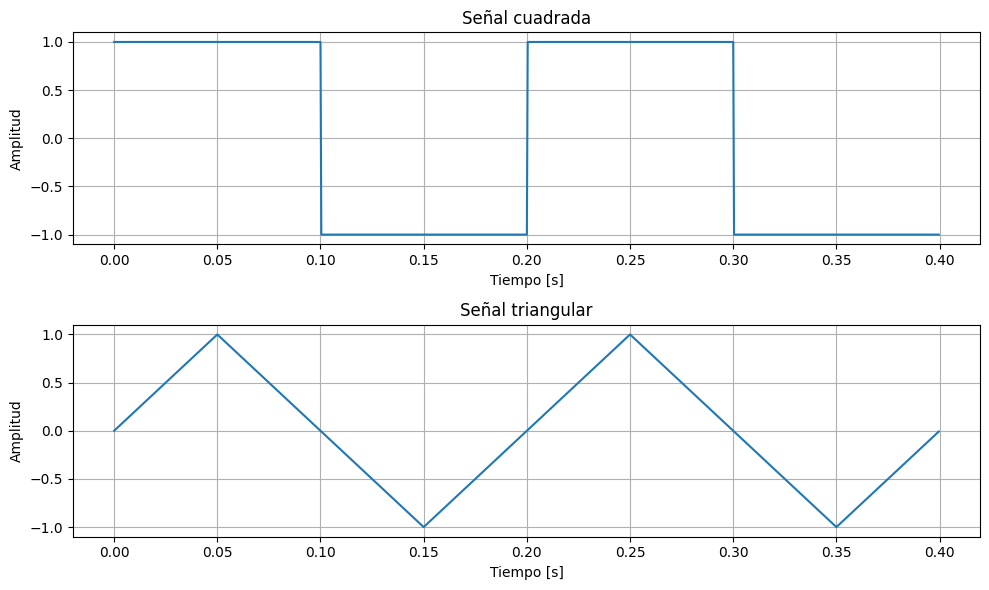

In [78]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x_cuadrada)
plt.title("Señal cuadrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, x_triangular)
plt.title("Señal triangular")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

d) Cree una función que reciba una señal periódica, y devuelva sus coeficientes de la serie de Fourier (forma exponencial), calculados mediante NumPy.

In [79]:
def coeficientes_fourier(x):
    N = len(x)
    
    # Transformada rápida de Fourier
    C = np.fft.fft(x)
    
    # Normalización
    C = C / N
    
    # Reorganizar las frecuencias
    C = np.fft.fftshift(C)
    
    return C



e) Aplique la función anterior a la señal cuadrada y a la señal triangular, y obtenga sus respectivos coeficientes.

In [80]:
C_cuadrada = coeficientes_fourier(x_cuadrada)

C_triangular = coeficientes_fourier(x_triangular)

print(C_cuadrada)
print(C_triangular)

[ 0.002+0.00000000e+00j  0.002+0.00000000e+00j -0.002+2.51330720e-05j
  0.002+0.00000000e+00j  0.002+0.00000000e+00j  0.002+0.00000000e+00j
 -0.002+7.54071548e-05j  0.002+0.00000000e+00j  0.002+0.00000000e+00j
  0.002+0.00000000e+00j -0.002+1.25705064e-04j  0.002+0.00000000e+00j
  0.002+0.00000000e+00j  0.002+0.00000000e+00j -0.002+1.76042718e-04j
  0.002+0.00000000e+00j  0.002+0.00000000e+00j  0.002+0.00000000e+00j
 -0.002+2.26436085e-04j  0.002+0.00000000e+00j  0.002+0.00000000e+00j
  0.002+0.00000000e+00j -0.002+2.76901203e-04j  0.002+0.00000000e+00j
  0.002+0.00000000e+00j  0.002+0.00000000e+00j -0.002+3.27454202e-04j
  0.002+0.00000000e+00j  0.002+0.00000000e+00j  0.002+0.00000000e+00j
 -0.002+3.78111325e-04j  0.002+0.00000000e+00j  0.002+0.00000000e+00j
  0.002+0.00000000e+00j -0.002+4.28888945e-04j  0.002+0.00000000e+00j
  0.002+0.00000000e+00j  0.002+0.00000000e+00j -0.002+4.79803592e-04j
  0.002+0.00000000e+00j  0.002+0.00000000e+00j  0.002+0.00000000e+00j
 -0.002+5.30871971e-

f) Cree una función que reciba un conjunto de coeficientes de Fourier y grafique el espectro de magnitud y el espectro de fase correspondientes.

In [81]:
frecuencias = np.fft.fftshift(np.fft.fftfreq(N, d=T0/N))

def graficar_espectros(C, frecuencias, titulo):
    
    # Calcular magnitud y fase
    magnitud = np.abs(C)
    fase = np.angle(C)
    
    # Crear figura
    plt.figure(figsize=(10, 6))
    
    # -------------------------
    # Espectro de magnitud
    # -------------------------
    plt.subplot(2, 1, 1)
    plt.stem(frecuencias, magnitud)
    plt.title("Espectro de magnitud - " + titulo)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|C_k|")
    plt.grid(True)
    
    # -------------------------
    # Espectro de fase
    # -------------------------
    plt.subplot(2, 1, 2)
    plt.stem(frecuencias, fase)
    plt.title("Espectro de fase - " + titulo)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Fase [rad]")
    plt.grid(True)
    
    # Ajustar espacios
    plt.tight_layout()
    
    # Mostrar
    plt.show()


g) Grafique los espectros de magnitud y fase de la señal cuadrada y de la señal triangular.

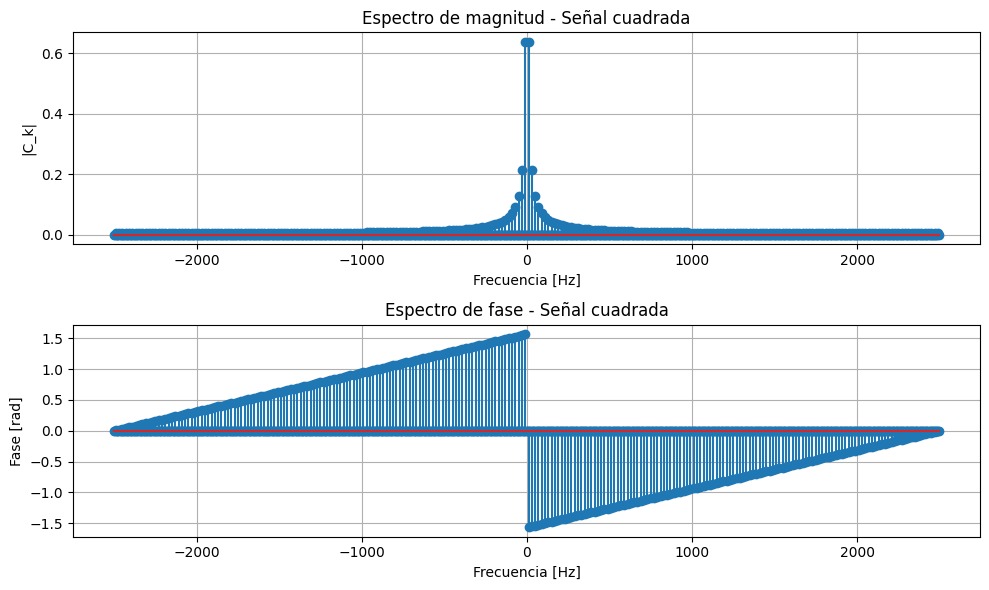

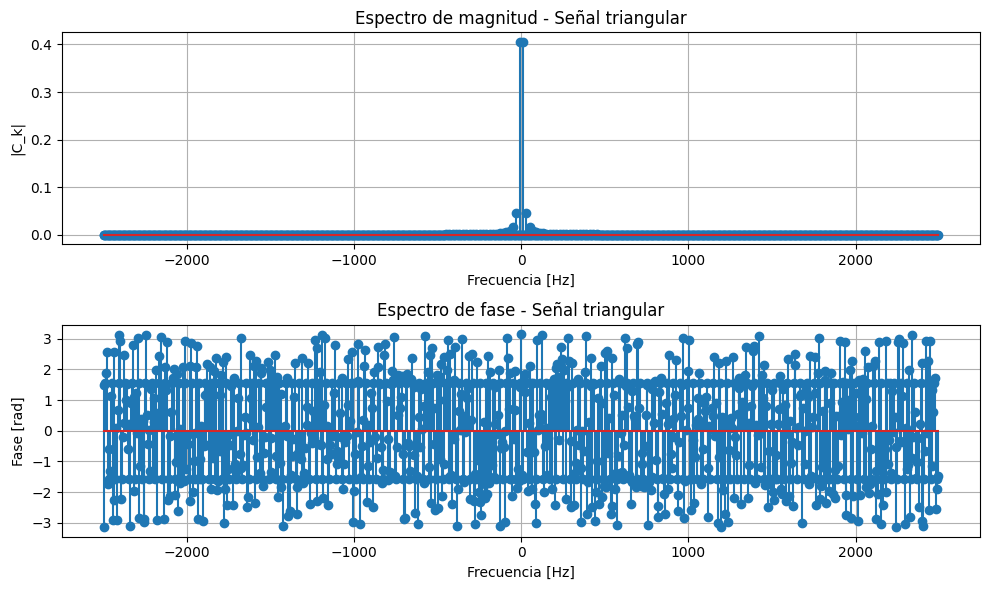

In [71]:
graficar_espectros(C_cuadrada,frecuencias,"Señal cuadrada")

graficar_espectros(C_triangular,frecuencias,"Señal triangular")

h) Cree una función que reconstruya una señal a partir de una suma de senos (armónicos), recibiendo como parámetros los coeficientes de Fourier y el número de armónicos a utilizar.

In [82]:
def reconstruir_señal(C, t, f0, num_armonicos):
    
    N = len(C)
    
    # Índices de los coeficientes
    k = np.arange(-N//2, N//2)
    
    # Frecuencia angular fundamental
    w0 = 2 * np.pi * f0
    
    # Señal reconstruida
    x_reconstruida = np.zeros(len(t), dtype=complex)
    
    # Seleccionar los armónicos
    for i in range(len(k)):
        
        if abs(k[i]) <= num_armonicos:
            
            x_reconstruida += C[i] * np.exp(
                1j * k[i] * w0 * t
            )
    
    # Como la señal original es real,
    # tomamos la parte real
    return np.real(x_reconstruida)



i) Reconstruya la señal cuadrada y la señal triangular utilizando N = 1, 3, 5, 20 y 50 armónicos, y grafique cada reconstrucción junto con la señal original.

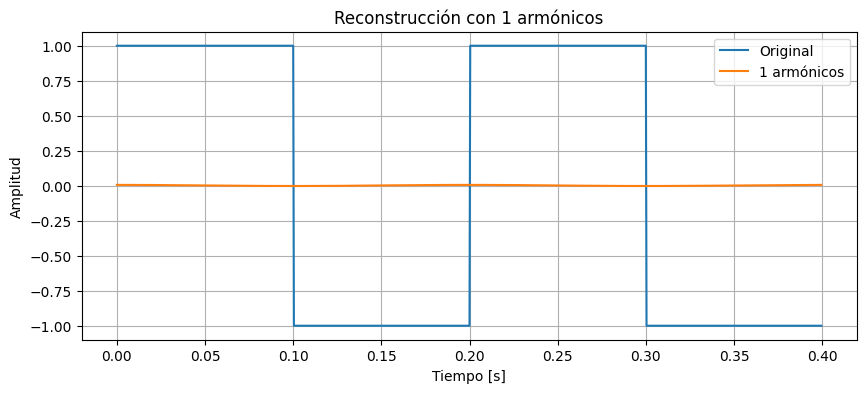

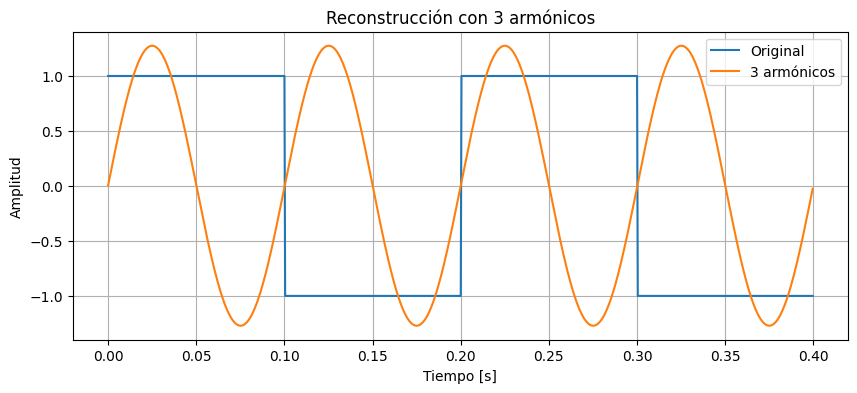

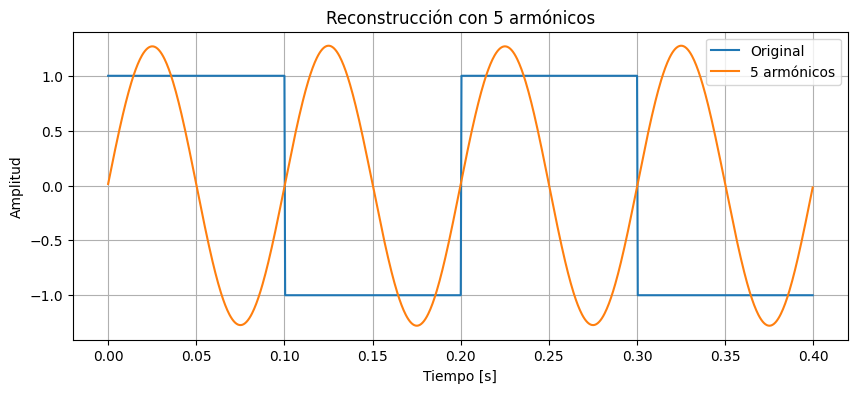

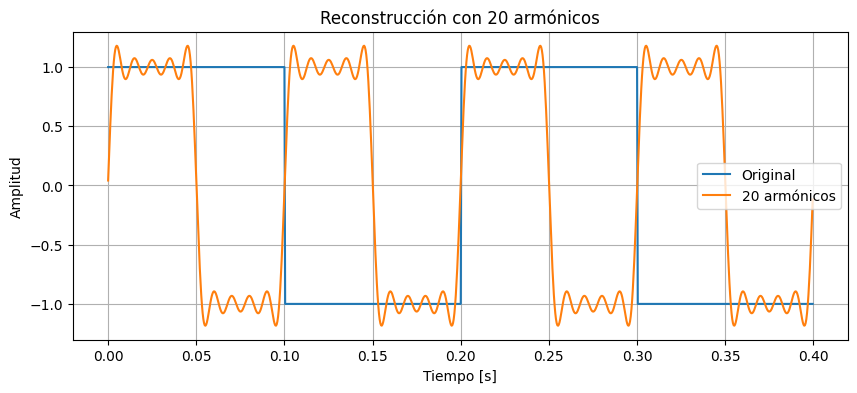

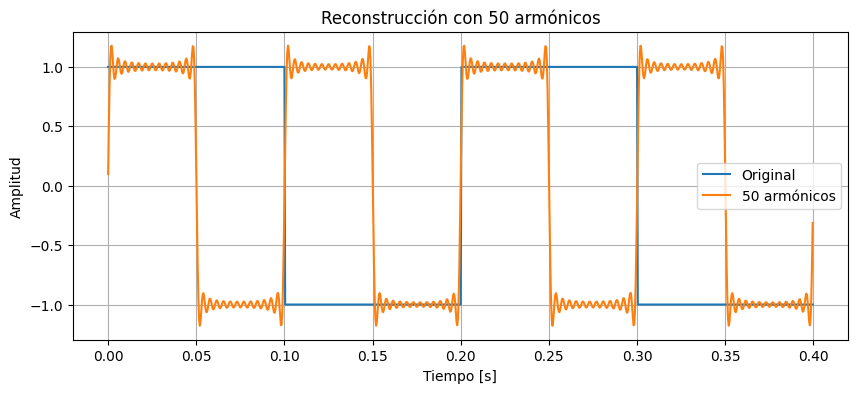

In [84]:
C_cuadrada = coeficientes_fourier(x_cuadrada)

armonicos = [1, 3, 5, 20, 50]

for n in armonicos:

    x_reconstruida = reconstruir_señal(
        C_cuadrada,
        t,
        f0,
        n
    )

    plt.figure(figsize=(10, 4))

    plt.plot(t, x_cuadrada, label="Original")
    plt.plot(t, x_reconstruida, label=f"{n} armónicos")

    plt.title(f"Reconstrucción con {n} armónicos")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()

    plt.show()


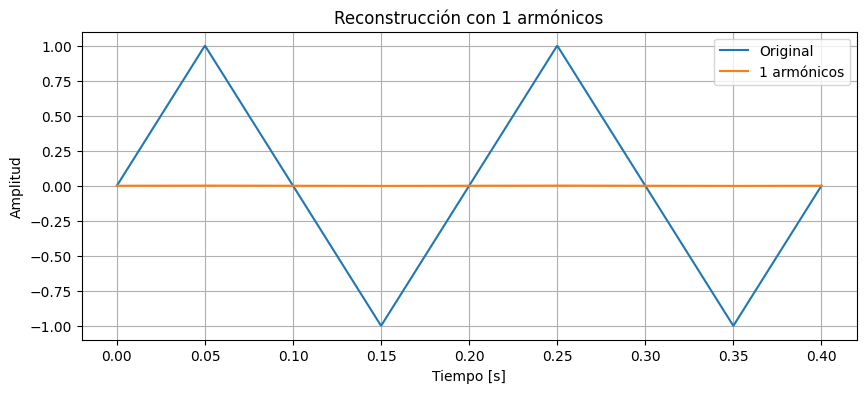

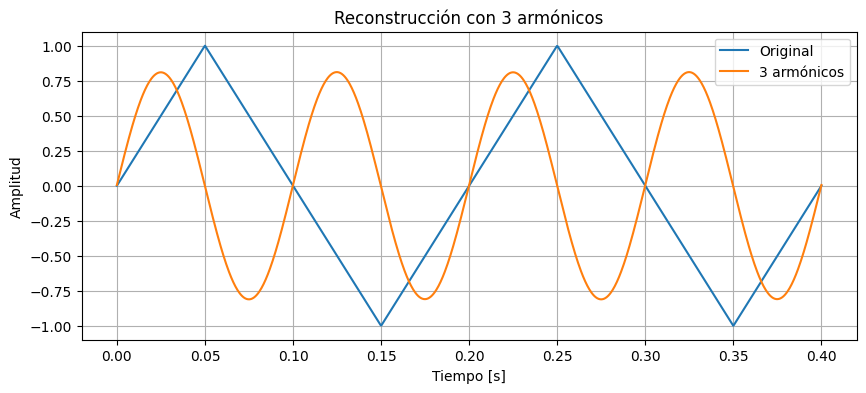

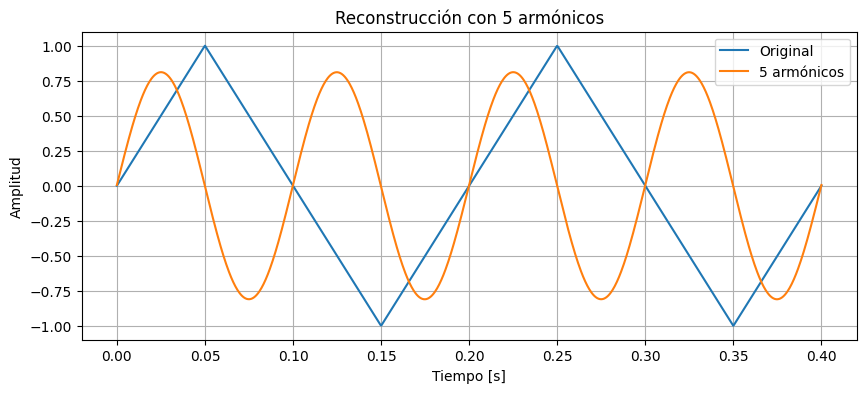

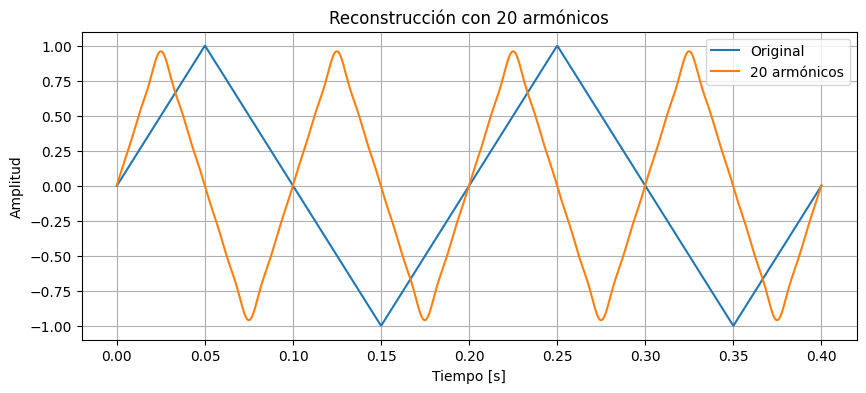

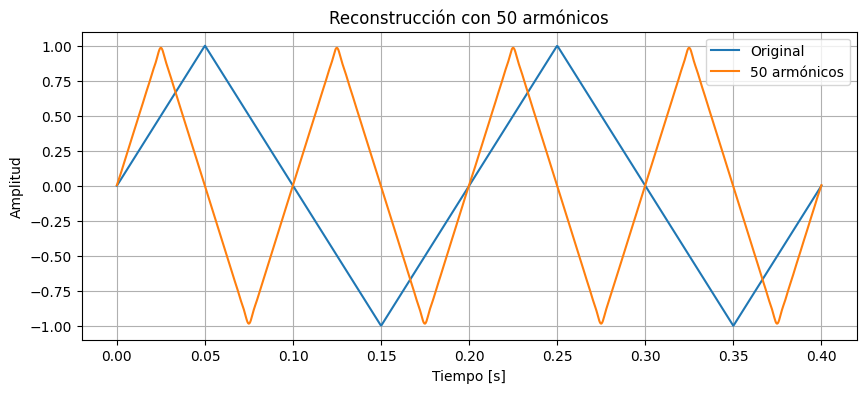

In [38]:

for n in armonicos:
    
    x_reconstruida = reconstruir_señal(
        C_triangular,
        t,
        f0,
        n
    )
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(t, x_triangular, label="Original")
    plt.plot(t, x_reconstruida, label=f"{n} armónicos")
    
    plt.title(f"Reconstrucción con {n} armónicos")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    
    plt.show()

j) Consulte, analice y describa el fenómeno de Gibbs observado en las reconstrucciones de la señal cuadrada.

El fenómeno de Gibbs se presenta durante la reconstrucción de la señal cuadrada mediante una cantidad finita de armónicos de Fourier. La señal cuadrada posee discontinuidades debido a sus cambios bruscos entre sus niveles de amplitud. Al aproximar estos cambios mediante una suma limitada de componentes sinusoidales, aparecen oscilaciones alrededor de las discontinuidades.

Al aumentar progresivamente el número de armónicos utilizados en la reconstrucción, por ejemplo de 1, 3, 5, 20 hasta 50 armónicos, la señal reconstruida se aproxima cada vez más a la señal cuadrada original. Sin embargo, las oscilaciones cercanas a los puntos de discontinuidad no desaparecen completamente. En cambio, se concentran en una región cada vez más pequeña alrededor del salto.

Este comportamiento corresponde al fenómeno de Gibbs. Por lo tanto, aumentar el número de armónicos mejora la aproximación de la señal en la mayor parte del período, pero no elimina completamente el sobrepico que aparece cerca de las discontinuidades. Este fenómeno es característico de la reconstrucción mediante series de Fourier de señales que presentan cambios abruptos.